#**Single-bit arbiter PUF**

## **1. High Level Definition**
An Arbiter Physically Unclonable Function (PUF) is a security primitive that leverages the inherent and unavoidable variations in the manufacturing process of integrated circuits to create a unique digital fingerprint for a specific chip. As one of the earliest and most well-known types of PUFs, the Arbiter PUF is designed to be a lightweight and cost-effective solution for hardware security. The core principle of a PUF is that it is easy to evaluate but practically impossible to clone, as creating an exact physical copy of the microscopic variations within a chip is infeasible.

The operation of an Arbiter PUF is based on a "race" between two identical electrical signals. The PUF circuit consists of a series of stages, each containing a switch. An input signal, known as a "challenge," is applied to these switches, which then determines the propagation path for the two signals. As the signals travel through these paths, they accumulate slight delays due to the unique physical characteristics of the transistors and wires at each stage. At the end of the paths, an "arbiter," typically a latch, determines which of the two signals arrived first. This outcome, a single binary digit (0 or 1), is the "response" to the given challenge. By applying many different challenges, a large set of challenge-response pairs can be generated, forming a unique identifier for the device.

While Arbiter PUFs are advantageous for applications like device authentication in resource-constrained environments, they are vulnerable to modeling attacks. An attacker can use machine learning algorithms to build a software model of the PUF that can predict its responses to new challenges with high accuracy after observing a limited number of challenge-response pairs. To counteract this vulnerability, more complex designs have been proposed, such as the XOR Arbiter PUF, which combines the outputs of multiple Arbiter PUFs to increase the difficulty of modeling and enhance the overall security and unpredictability of the system.



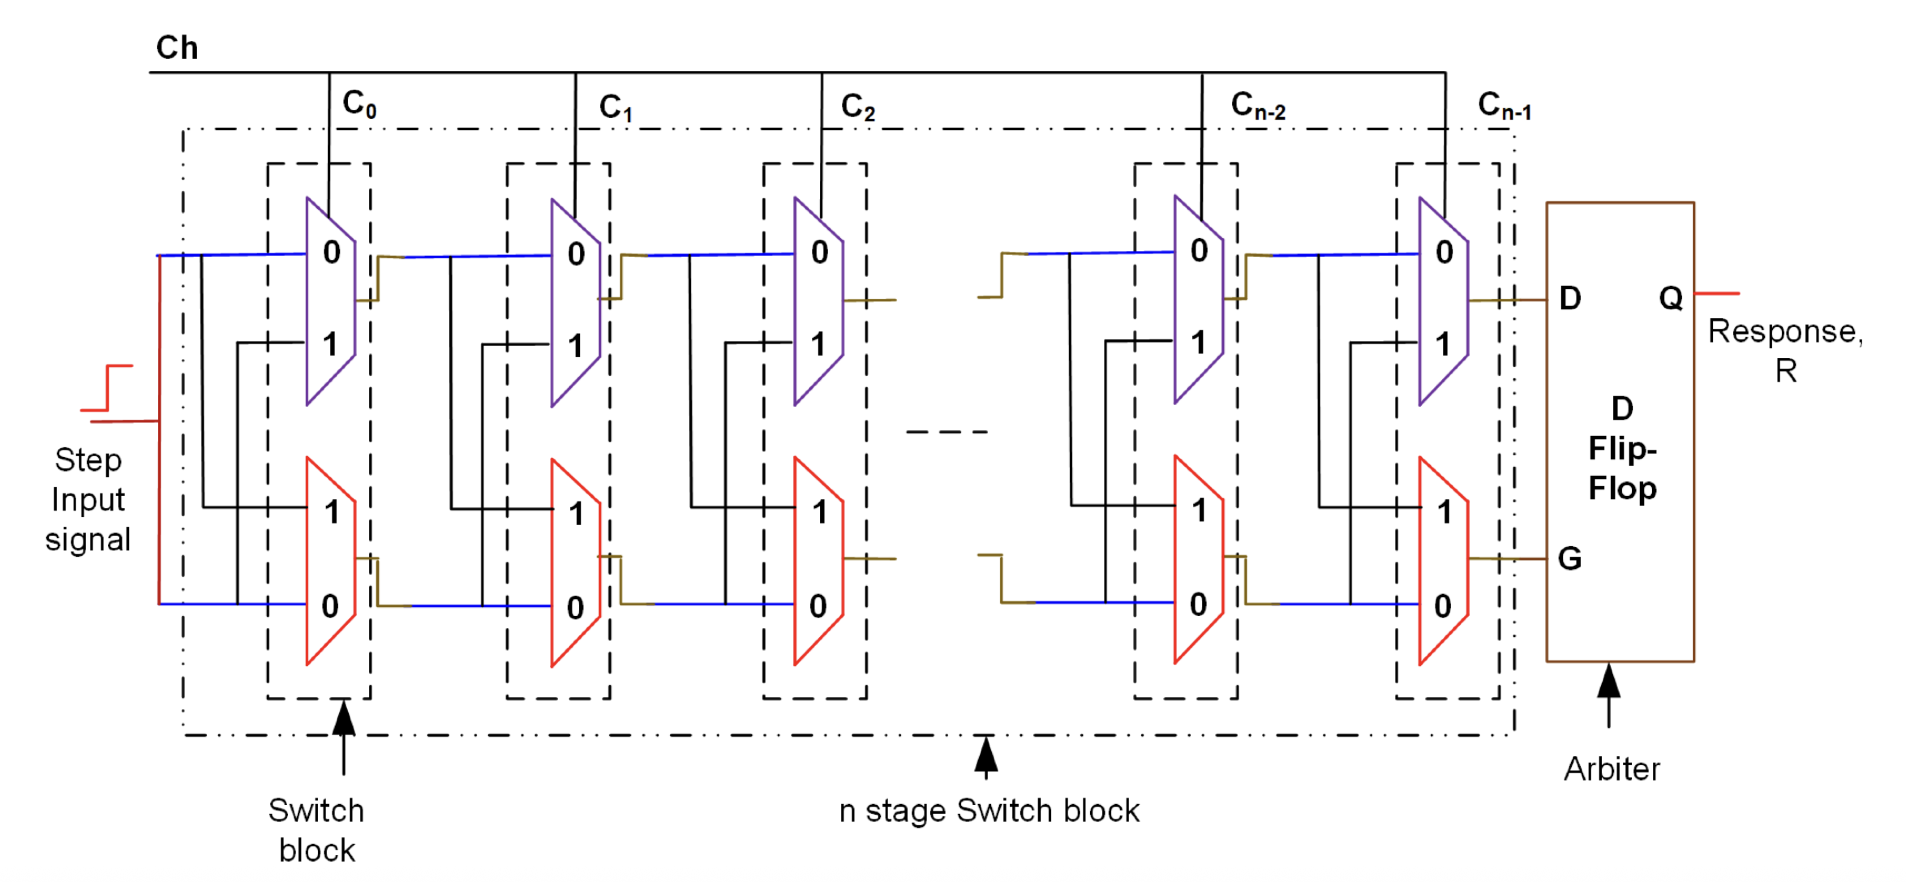


## **2. Terms**

HD = Hamming Distance

HW = Hamming Weight

Challenge = C = {c<sub>1</sub>c<sub>2</sub>...c<sub>M</sub>}

Response = R = {r<sub>1</sub>r<sub>2</sub>...r<sub>M</sub>}

R<sub>i</sub> = PUF<sub>i</sub>(C)




## **3. PUF Metrics**

In general, PUF evaluation metrics are divided into inter-chip and intra-chip metrics, and include uniqueness, randomness, uniformity, reliability, bit-aliasing etc. A handful of them are introduced below.

- Inter-chip metric: between two chips with same PUF architecture and same C
  - Uniqueness: HD between two response pairs (R<sub>1</sub> and R<sub>2</sub>) for a given C. Ideally, observe 50% of bits flipped.
- Intra-chip metrics: in the same chip
  - Uniformity: Measure of 0's and 1's in a given R. Could be measured for a single R, or multiple R<sub>i</sub>. Average HW of R. Ideal value = 50%.
  - Reliability: Ideally, R<sub>i</sub> = PUF<sub>i</sub>(C) irrespective of temperature, volatage, or other physical variations, but this is often not the case. For L+1 samples, evaluate CRP and compare HD of R<sub>1</sub> against all other R<sub>1</sub> to evaluate reliability. Ideal value should be 100% reliable, but in practice, it is lower.


[Further reading on basics of Arbiter PUFs](https://ieeexplore.ieee.org/document/10091112)



##**4. Modeling a single-bit N-stage Arbiter PUF**

A single stage of a MUX based arbiter PUF is characterized by 4 paths - 2 direct paths from upper input to their respective MUXes, and 2 cross paths from the inputs to the MUX above/below them. We model these delays as uniform distribution with a fixed mean and standard dev, which can be changed by modifying ```__init__``` below. This is repeated for N-stages.

Variability in physical conditions is modeled by uniform noise. This is a very simplistic model that likely does not represent physical phenomenon like temperature or voltage variations.




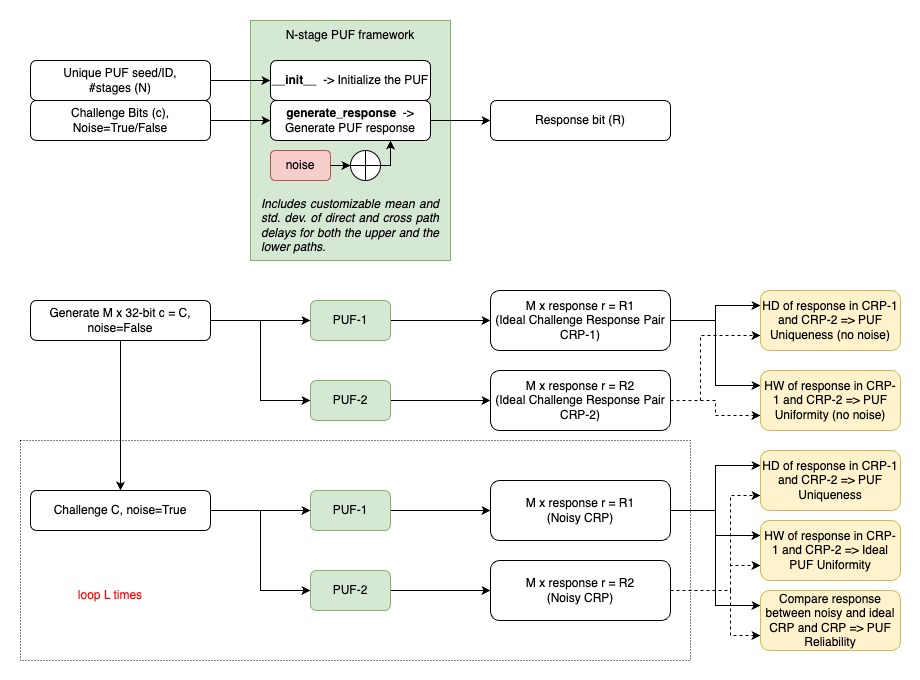

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class ArbiterPUF:
    """Represents an Arbiter Physical Unclonable Function."""

    def __init__(self, num_stages, unique_ID, direct_delay_mean=50.0, direct_delay_std_dev=1/5, cross_delay_mean=50.5, cross_delay_std_dev=1/5, noise_std_dev=1/10):
        """
        Initializes the ArbiterPUF with separate delay distributions for direct and cross paths.

        Args:
            num_stages: The number of stages in the PUF.
            direct_delay_mean: The mean delay for direct paths (upper to upper or lower to lower).
            direct_delay_scale: The standard deviation for direct path delays.
            cross_delay_mean: The mean delay for cross paths (upper to lower or lower to upper).
            cross_delay_scale: The standard deviation for cross path delays.
        """

        np.random.seed(int(unique_ID)) # You can change the seed value

        self.num_stages = num_stages
        self.direct_delay_mean = direct_delay_mean
        self.direct_delay_scale = direct_delay_std_dev
        self.cross_delay_mean = cross_delay_mean
        self.cross_delay_scale = cross_delay_std_dev

        # This is used to model circuit characteristics varying as a result of environmental changes
        self.noise1_mean = 0
        self.noise1_scale = noise_std_dev
        self.noise2_mean = 0
        self.noise2_scale = noise_std_dev

        # Generate delays for each stage and each path type (direct and cross)
        self.direct_delays = np.random.normal(loc=self.direct_delay_mean, scale=self.direct_delay_scale, size=(self.num_stages, 2))
        self.cross_delays = np.random.normal(loc=self.cross_delay_mean, scale=self.cross_delay_scale, size=(self.num_stages, 2))


    def generate_response(self, challenge, noise = True):
        """
        Generates the response bit for a given challenge, considering direct and cross path delays.

        Args:
            challenge: A list or array of binary values representing the challenge bits.

        Returns:
            The response bit (0 or 1).
        """
        if len(challenge) != self.num_stages:
            raise ValueError(f"Challenge length must match the number of stages ({self.num_stages})")

        self.noise = noise
        upper_path_delay = 0
        lower_path_delay = 0

        direct_noisy_delays = self.direct_delays
        cross_noisy_delays = self.cross_delays

        if(self.noise):
          direct_noisy_delays += np.concatenate([np.zeros((num_stages//2,2)), np.random.normal(loc=self.noise1_mean, scale=self.noise1_scale, size=(num_stages//4, 2)), np.zeros((num_stages - num_stages//2 - num_stages//4,2))])
          cross_noisy_delays += np.concatenate([np.zeros((num_stages//2,2)), np.random.normal(loc=self.noise2_mean, scale=self.noise2_scale, size=(num_stages//4, 2)), np.zeros((num_stages - num_stages//2 - num_stages//4,2))])


        for i in range(self.num_stages):
            challenge_bit = challenge[i]
            if challenge_bit == 0:
                # Direct path
                upper_path_delay += direct_noisy_delays[i][0]
                lower_path_delay += direct_noisy_delays[i][1]
            elif challenge_bit == 1:
                # Cross path
                upper_path_delay += cross_noisy_delays[i][0]
                lower_path_delay += cross_noisy_delays[i][1]
            else:
                raise ValueError("Challenge bits must be binary (0 or 1)")

        return 0 if upper_path_delay < lower_path_delay else 1

##**5. Generate a single unique PUF and the Challenges for the PUF**

We prompt the user for a unique ID which characterizes the PUF. This ID affects the PRNG seed, and hence affects the path delays in the MUX based arbiter PUF.

* **Question 1**: Update the code below to generate 2 PUFs (named ```puf1``` and ```puf2```), each with its own unique ID. Prompt the user for this unique ID, so it is reproducible.

* **Question 2**: Generate pairs of challenges and responses for the two PUFs. The challenges can be random, but fixed for all PUFs being tested. The responses are evaluated under ideal conditions with ```noise``` set to ```False```.

In [ ]:
num_challenges = 1000
num_stages = 32

# generate puf1 and puf2. Generate challenges and responses for PUF.


Type in a unique number that defines the uniqueness of the PUF-1 
10
Type in a unique number that defines the uniqueness of the PUF-2 
15


##**6. Plot of path delays without noise**

* **Question 3**: Generate a plot of all direct and cross delays in both upper and lower paths of the two PUFs. Do your observations match the plots based on the mean and stddev parameters of the PUFs?

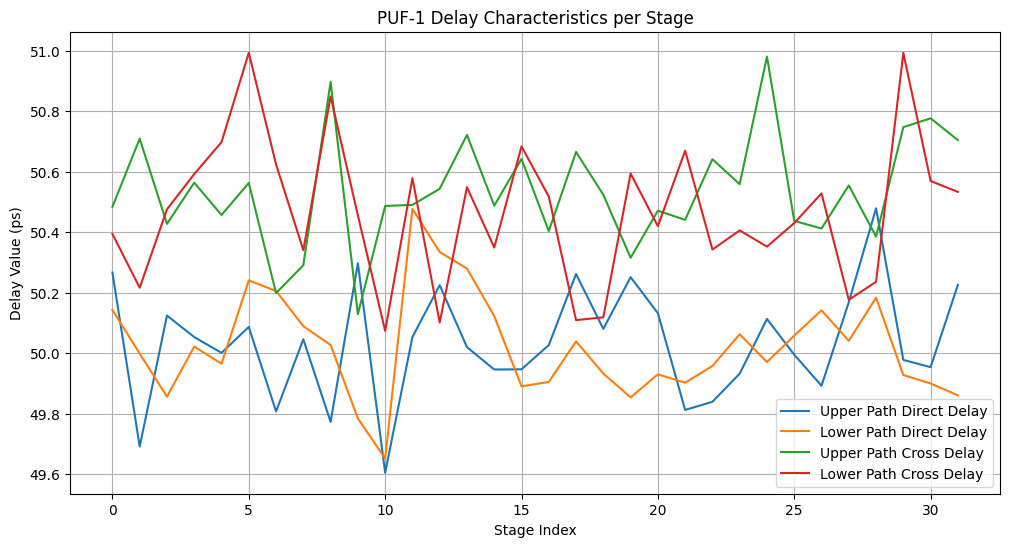

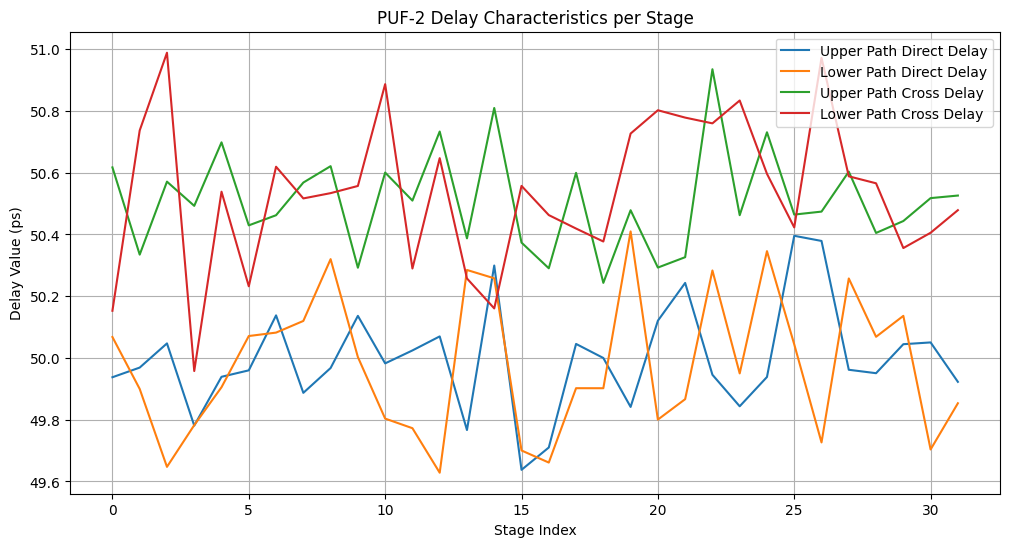

In [ ]:
import matplotlib.pyplot as plt

# Plot direct and cross delays of both PUFs

## **7. Uniqueness of PUF**

* **Question 4**: Evaluate the uniqueness of this PUF architecture (using Hamming Distance), comparing PUF-1 and PUF-2, under noisy and ideal conditions. Note that you have the ideal response of the PUFs from the challenge response pairs. However, you do not yet have the challenge-reponse pairs under noisy conditions.
* **Question 5**: Is there any difference between the uniqueness observed under ideal and noisy conditions?


In [ ]:
responses_puf1 = []
responses_puf2 = []
noise = True

# Calculate Hamming distance for ideal CRPs
# Calculate uniqueness for ideal CRPs

num_iterations = 100

# calculate hamming distance under noise for multiple iterations to calculate uniqueness under noise.



Uniqueness without noise
------------------------
Number of challenges   = 1000
Total Hamming distance = 502
Total bits compared    = 1000
Uniqueness percentage  = 50.2%

Uniqueness with noise
---------------------
Number of challenges   = 1000
Number of iterations   = 100
Total Hamming distance = 59094
Total bits compared    = 100000
Uniqueness percentage  = 59.094%



##**8. Uniformity of the PUF**

* **Question 6**: Evaluate the uniformity of PUF-1 and PUF-2 (using Hamming Weight) under noisy and ideal conditions.

In [ ]:
# Calculate HW for ideal CRP, and uniformity without noise.


num_iterations = 100
# for multiple iterations calculate HW under noise, and then the uniformity.


Uniformity without noise
------------------------
Number of challenges                = 1000
HW of PUF-1 response with ideal CRP = 876
HW of PUF-2 response with ideal CRP = 442
Uniformity of PUF-1                 = 87.6%
Uniformity of PUF-2                 = 44.2%

Uniformity with noise
---------------------
Number of challenges   = 1000
Number of iterations   = 100
Total bits compared    = 100000
HW of PUF-1 response   = 40710
HW of PUF-2 response   = 24000
Uniformity of PUF-1    = 40.71%
Uniformity of PUF-2    = 24.0%



##**9. Reliability of the PUF**

* **Question 7**: Quantify the reliability of the two PUFs under noisy conditions.

In [ ]:
# 1. To evaluate reliability, simulate the responses for the same set of challenges multiple times
num_iterations = 100
#calculate reliability under noise for multiple iterations

Reliability under noise
-----------------------
Number of challenges          = 1000
Number of iterations          = 100
Average Reliability for PUF-1 = 93.23%
Average Reliability for PUF-2 = 96.05%



##**10.**

* **Question 8**: Repeat these sets of experiments with another set of PUFs (changing either the Unique IDs, or the mean and std dev of the path delays, or both) and note your observations.